In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv('/content/Sales.csv')
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
(200, 5)


In [7]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [8]:
df.drop("Unnamed: 0", axis=1, inplace=True)

print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [9]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


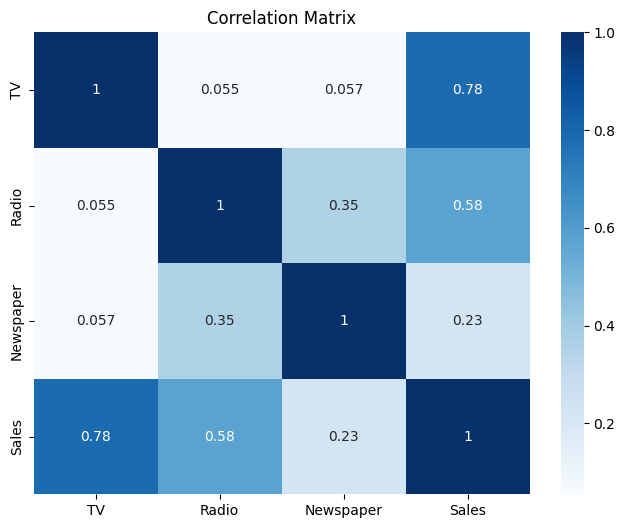

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

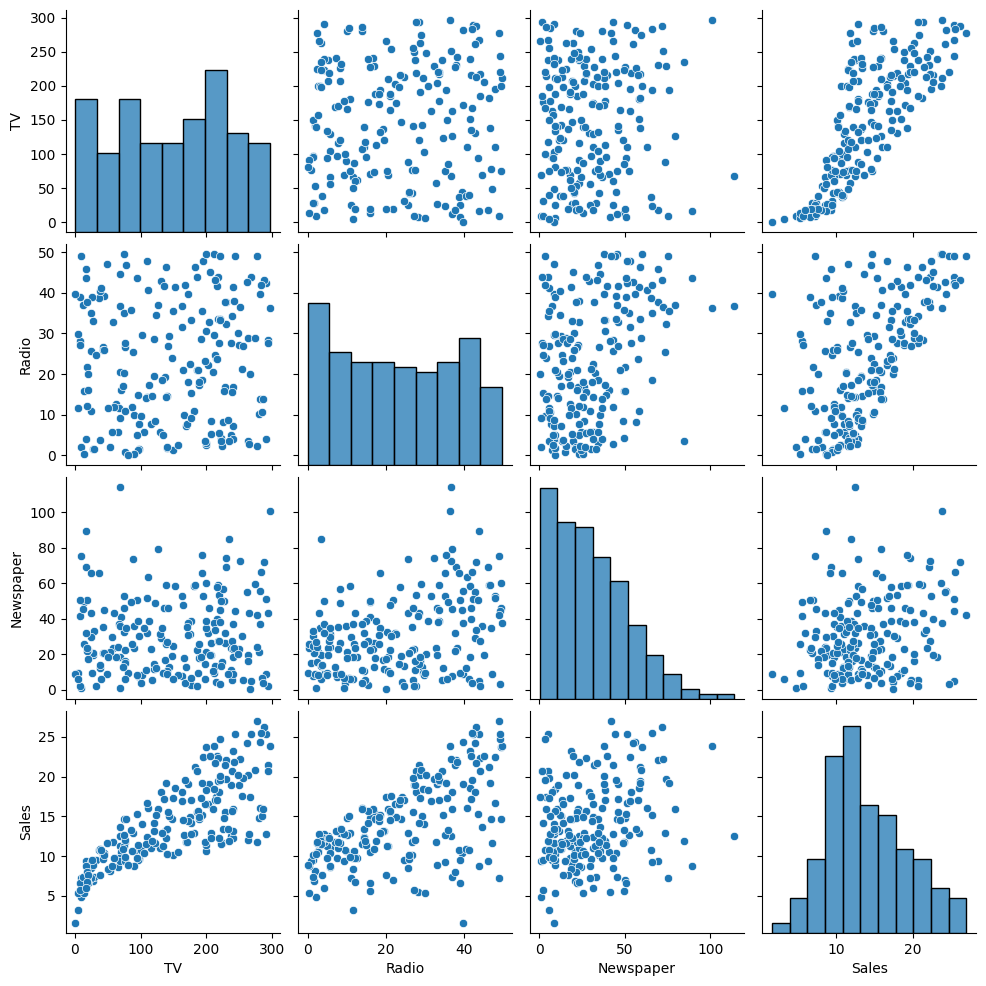

In [11]:
sns.pairplot(df)
plt.show()

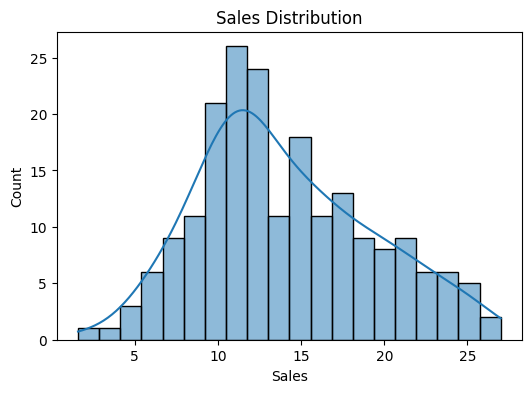

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.show()

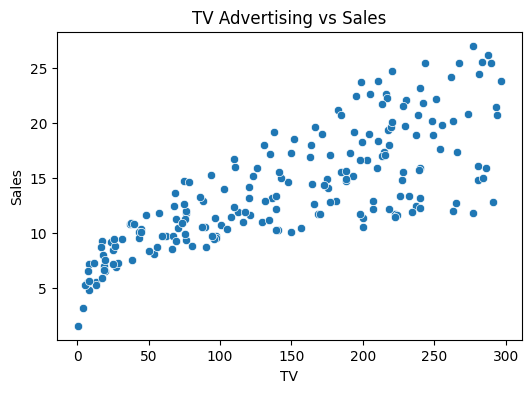

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.show()

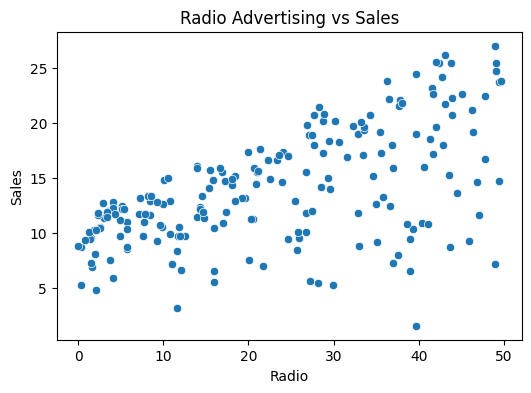

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

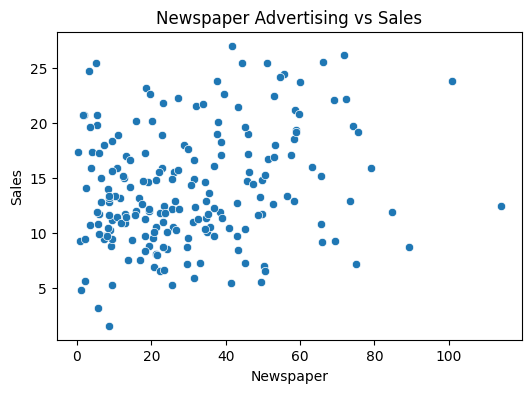

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

In [16]:
X = df[['TV', 'Radio', 'Newspaper']]

In [17]:
y = df['Sales']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160, 3)
(40, 3)


In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [20]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)

print(coefficients)

Intercept: 2.979067338122629
           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761


In [21]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [22]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.4607567168117603


In [23]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3.1740973539761033


In [24]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.78159966153345


In [25]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.899438024100912


In [26]:
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(results.head(10))

     Actual Sales  Predicted Sales
95           16.9        16.408024
15           22.4        20.889882
30           21.4        21.553843
158           7.3        10.608503
128          24.7        22.112373
115          12.6        13.105592
69           22.3        21.057192
170           8.4         7.461010
174          11.5        13.606346
45           14.9        15.155070


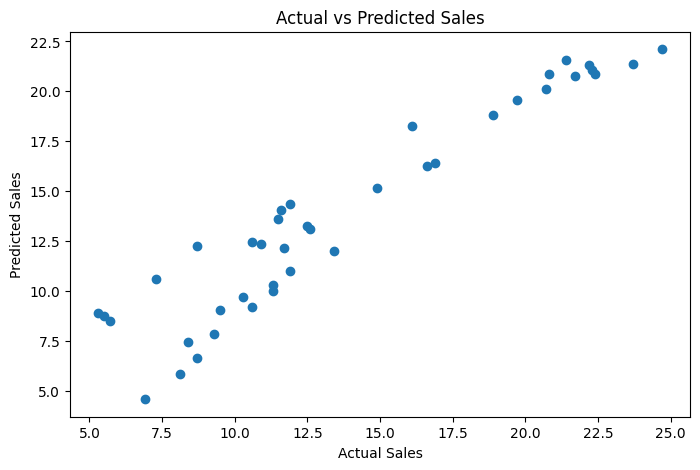

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [28]:
new_data = pd.DataFrame({
    'TV':[150],
    'Radio':[20],
    'Newspaper':[30]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 13.555229473358624
